In [1]:
from datetime import datetime
now = datetime.now()
print("Last run on:", now.strftime("%A, %B %d, %Y - %I:%M:%S %p"))

Last run on: Wednesday, October 08, 2025 - 02:33:50 PM


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
import os as os
os.chdir('C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/')
%matplotlib inline
from WildAlertpy import WRMDalert as alert
from WildAlertpy import read_data as read_data
from WildAlertpy import anomaly_2 as an
data_path = 'C:/Users/prana/Desktop/directory/WildAlert_AnamolyModels/data/wildalert exports/'
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.style as style
import numpy as np
style.use('fivethirtyeight')
plt.rcParams['font.family'] = 'Times New Roman'
sns.set_context("notebook", font_scale=1.30, rc={"lines.linewidth": 0.8})


def run_full_anomaly_analysis(folder_path, sigma=2, window_size=10, time_bin='W'):
    from WildAlertpy import anomaly_2 as an

    summary_dfs = []
    sensitivity_dfs = []

    # Loop through all files
    for fname in os.listdir(folder_path):
        if not fname.endswith('.xlsx'):
            continue
        full_path = os.path.join(folder_path, fname)
        full_path = full_path.replace('.xlsx', '') 
        print(f"\n=== Processing: {fname} ===")

        ana, comp_df, sen_df = an.plot_anomalies(
            filename=full_path,
            sigma=sigma,
            window_size=window_size,
            time_bin=time_bin,
            plot=False,
            verbose=False,
            save=False
        )
        comp_df['source_file'] = fname
        sen_df['source_file'] = fname

        summary_dfs.append(comp_df)
        sensitivity_dfs.append(sen_df)

    # Combine
    combined_summary_df = pd.concat(summary_dfs, ignore_index=True)
    combined_sensitivity_df = pd.concat(sensitivity_dfs, ignore_index=True)

    # Filter window sizes
    filtered_sensitivity_df = combined_sensitivity_df[
        combined_sensitivity_df['window_size'].isin([5, 7, 10, 15, 20])
    ].copy()

    # Normalize anomaly counts
    filtered_sensitivity_df['ae_anomaly_rate'] = filtered_sensitivity_df['ae_anomaly_count'] / filtered_sensitivity_df['ae_anomaly_count'].max()
    filtered_sensitivity_df['iof_anomaly_rate'] = filtered_sensitivity_df['iof_anomaly_count'] / filtered_sensitivity_df['iof_anomaly_count'].max()

    # Window size effect
    ws_effect = filtered_sensitivity_df.groupby('window_size')[
        ['ae_anomaly_count', 'iof_anomaly_count']
    ].agg(['mean', 'std']).reset_index()
    ws_effect.columns = ['window_size', 'ae_mean', 'ae_std', 'iof_mean', 'iof_std']

    # Plot
    plt.figure(figsize=(10, 6))
    plt.errorbar(ws_effect['window_size'], ws_effect['ae_mean'], yerr=ws_effect['ae_std'], label='Autoencoder', fmt='-o')
    plt.errorbar(ws_effect['window_size'], ws_effect['iof_mean'], yerr=ws_effect['iof_std'], label='Isolation Forest', fmt='-o')
    plt.xlabel('Window Size')
    plt.ylabel('Mean Anomalies Detected')
    plt.title('Effect of Window Size on Detected Anomalies')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Compute stability
    def compute_stability(df, model_col):
        return df.groupby(['add_outliers', 'add_trend', 'contamination'])[model_col].std().reset_index().rename(columns={model_col: 'std_dev'})

    ae_stability = compute_stability(filtered_sensitivity_df, 'ae_anomaly_count')
    ae_stability['model'] = 'Autoencoder'
    iof_stability = compute_stability(filtered_sensitivity_df, 'iof_anomaly_count')
    iof_stability['model'] = 'Isolation Forest'
    stability_comparison = pd.concat([ae_stability, iof_stability], ignore_index=True)

    # Heatmaps
    def plot_stability_heatmaps(stability_df):
        for model in stability_df['model'].unique():
            model_df = stability_df[stability_df['model'] == model]
            model_df['Condition'] = model_df['add_outliers'].map({True: 'Outlier', False: 'NoOutlier'}) + ' & ' + \
                                    model_df['add_trend'].map({True: 'Trend', False: 'NoTrend'})
            heatmap_data = model_df.pivot(index='Condition', columns='contamination', values='std_dev')

            plt.figure(figsize=(8, 6))
            sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5)
            plt.title(f"{model} Stability (Lower Std Dev = More Stable)")
            plt.xlabel("Contamination Level")
            plt.ylabel("Condition (Outliers & Trend)")
            plt.tight_layout()
            plt.show()

    plot_stability_heatmaps(stability_comparison)

    # Sensitivity Models
    df = filtered_sensitivity_df.copy()
    df['add_outliers'] = df['add_outliers'].astype(str)
    df['add_trend'] = df['add_trend'].astype(str)

    model_ae = smf.ols("ae_anomaly_count ~ C(add_outliers) + C(add_trend) + contamination + window_size", data=df).fit()
    model_iof = smf.ols("iof_anomaly_count ~ C(add_outliers) + C(add_trend) + contamination + window_size", data=df).fit()

    print("\n=== Autoencoder Sensitivity Model ===")
    print(model_ae.summary())
    print("\n=== Isolation Forest Sensitivity Model ===")
    print(model_iof.summary())

    # Volcano-style summary
    def extract_volcano_data(model, model_name):
        summary_df = pd.DataFrame({
            'variable': model.params.index,
            'coef': model.params.values,
            'pval': model.pvalues.values
        }).query("variable != 'Intercept'")
        summary_df['neglog10_p'] = -np.log10(summary_df['pval'])
        summary_df['model'] = model_name
        return summary_df

    volcano_ae = extract_volcano_data(model_ae, "Autoencoder")
    volcano_iof = extract_volcano_data(model_iof, "Isolation Forest")
    volcano_all = pd.concat([volcano_ae, volcano_iof])

    # Labeling
    var_labels = {
        "C(add_outliers)[T.True]": "Outliers Added",
        'C(add_trend)[T.True]': "Trend Added",
        "contamination": "Contamination Level",
        "window_size": "Window Size"
    }

    for df in [volcano_ae, volcano_iof]:
        df['Variable'] = df['variable'].map(var_labels)

    # Side-by-side volcano
    def plot_side_by_side_volcano(volcano_ae, volcano_iof):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
        for ax, df, name in zip(axes, [volcano_ae, volcano_iof], ['Autoencoder', 'Isolation Forest']):
            df = df.copy().sort_values('coef')
            df['color'] = np.where(df['pval'] < 0.05, 'crimson', 'gray')
            df.set_index('Variable')['coef'].plot(kind='barh', color=df['color'], edgecolor='black', ax=ax)
            ax.axvline(0, color='black', linestyle='--')
            ax.set_title(name)
            ax.set_xlabel("Effect Size (Coefficient)")
        axes[0].set_ylabel("Predictor")
        plt.suptitle("Volcano-style Coefficient Plot Comparison")
        plt.tight_layout()
        plt.show()

    plot_side_by_side_volcano(volcano_ae, volcano_iof)

    # Metric summary
    combined_summary_df['Value'] = pd.to_numeric(combined_summary_df['Value'], errors='coerce')
    metric_stats = combined_summary_df.groupby('Metric')['Value'].agg(['mean', 'std']).reset_index()
    print("\n=== Metric Statistics ===")
    print(metric_stats)

    # Optional return
    return {
        "summary": combined_summary_df,
        "sensitivity": combined_sensitivity_df,
        "filtered_sensitivity": filtered_sensitivity_df,
        "ws_effect": ws_effect,
        "volcano_ae": volcano_ae,
        "volcano_iof": volcano_iof,
        "models": {
            "ae": model_ae,
            "iof": model_iof
        }
    }



=== Processing: black-vulture-in-florida.xlsx ===
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Fleiss' Kappa: 0.361
Cohen's Kappa (IOF vs AE): 0.362
running sensitivity
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
17/17

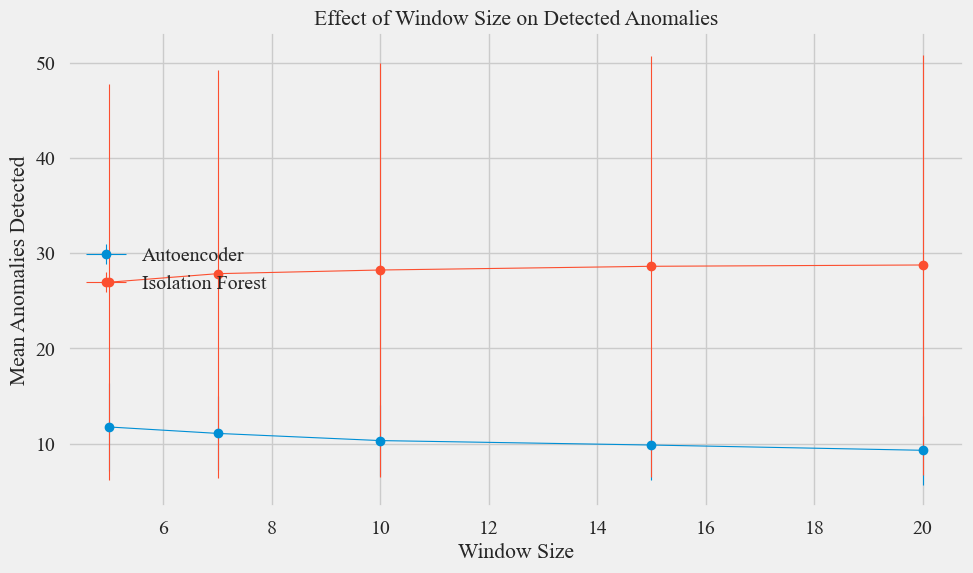

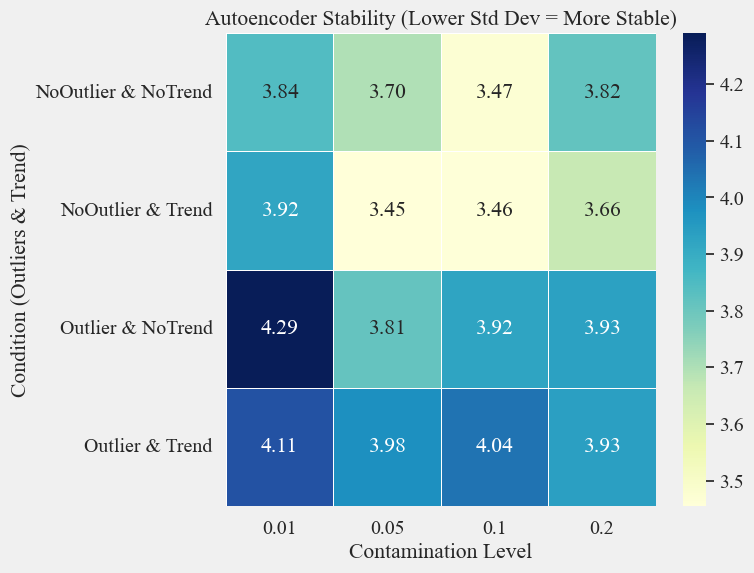

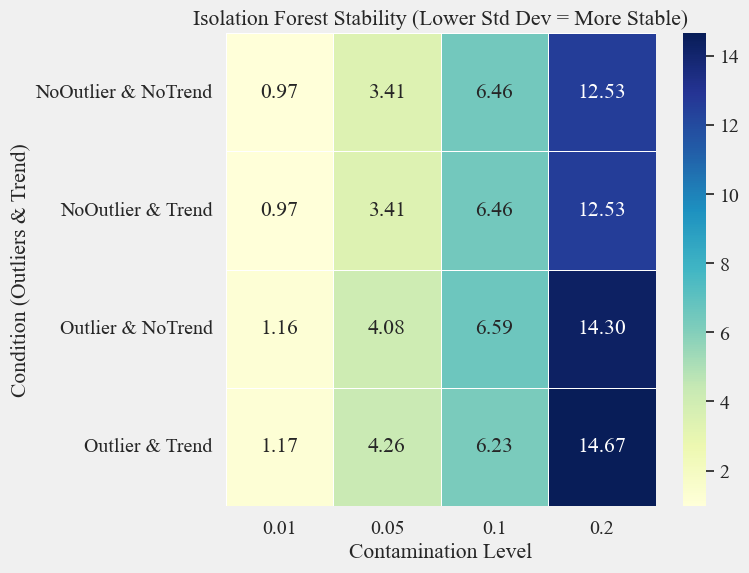


=== Autoencoder Sensitivity Model ===
                            OLS Regression Results                            
Dep. Variable:       ae_anomaly_count   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     78.22
Date:                Wed, 08 Oct 2025   Prob (F-statistic):           1.05e-61
Time:                        21:43:13   Log-Likelihood:                -5474.3
No. Observations:                2000   AIC:                         1.096e+04
Df Residuals:                    1995   BIC:                         1.099e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

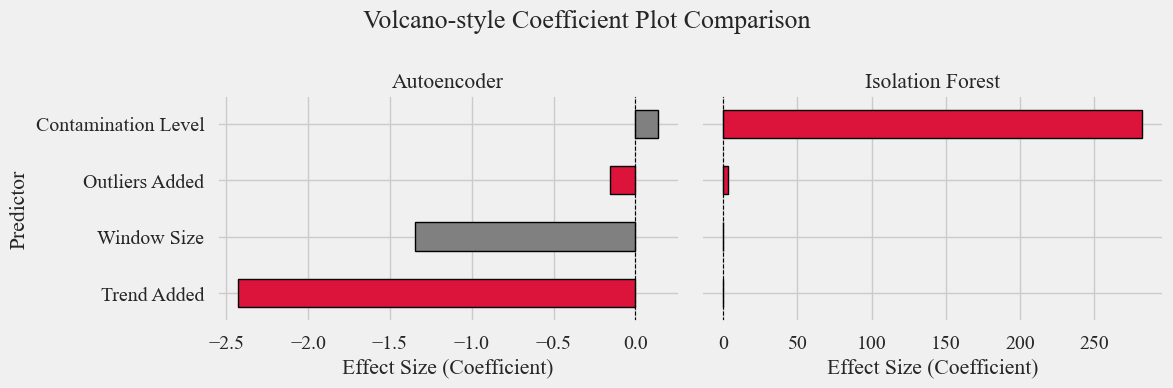


=== Metric Statistics ===
                               Metric       mean       std
0              % Overlap in Anomalies  19.349238  8.986389
1           Cohen’s Kappa (IOF vs AE)   0.247012  0.125110
2             Common anomalies (both)   5.480000  2.443150
3                 Fleiss’ Kappa (All)   0.265971  0.049041
4              Good at gradual trends        NaN       NaN
5      Jaccard Similarity (IOF vs AE)   0.162399  0.088420
6                  Robust to outliers        NaN       NaN
7          Sensitive to contamination        NaN       NaN
8   Sensitivity Test (Mean Anomalies)  19.267200  9.773560
9     Sensitivity Test (Mean Overlap)   3.947600  1.067892
10         Sensitivity to window size        NaN       NaN
11           Total anomalies detected  20.420000  9.992017
CPU times: total: 7h 3min 50s
Wall time: 7h 9min 14s


In [3]:
%%time
folder = r"C:\Users\prana\Desktop\directory\WildAlert_AnamolyModels\data\paper_exports\endemic"
results_endemic = run_full_anomaly_analysis(folder)


=== Processing: black-vulture-with-neurologic-disease-in-florida.xlsx ===
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Fleiss' Kappa: 0.170
Cohen's Kappa (IOF vs AE): 0.089
running sensitivity
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━

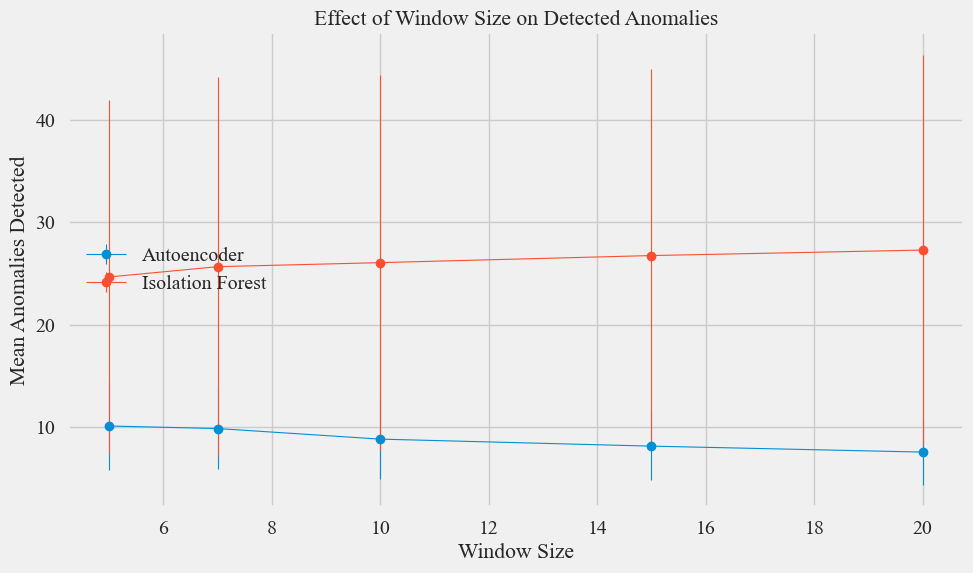

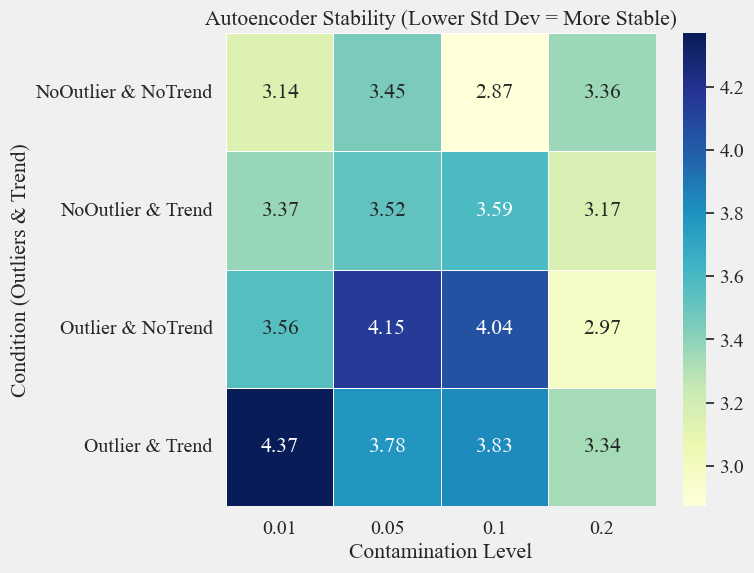

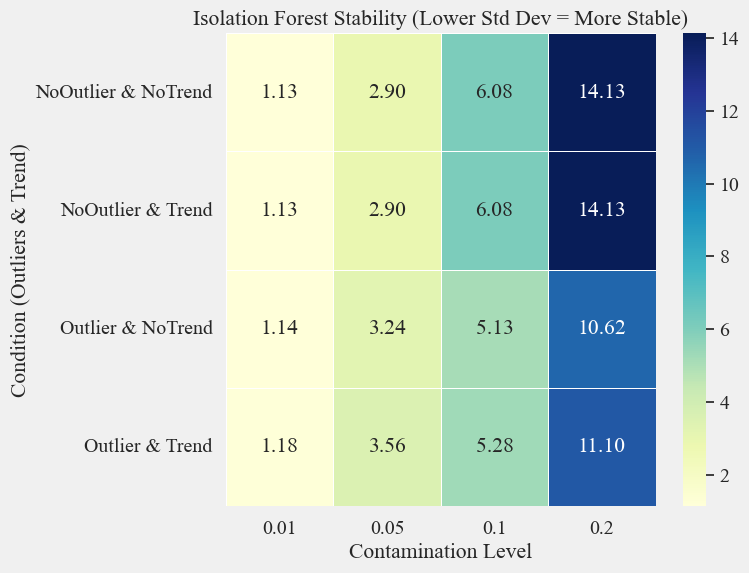


=== Autoencoder Sensitivity Model ===
                            OLS Regression Results                            
Dep. Variable:       ae_anomaly_count   R-squared:                       0.223
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     108.5
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           2.29e-81
Time:                        03:57:52   Log-Likelihood:                -4020.6
No. Observations:                1520   AIC:                             8051.
Df Residuals:                    1515   BIC:                             8078.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------

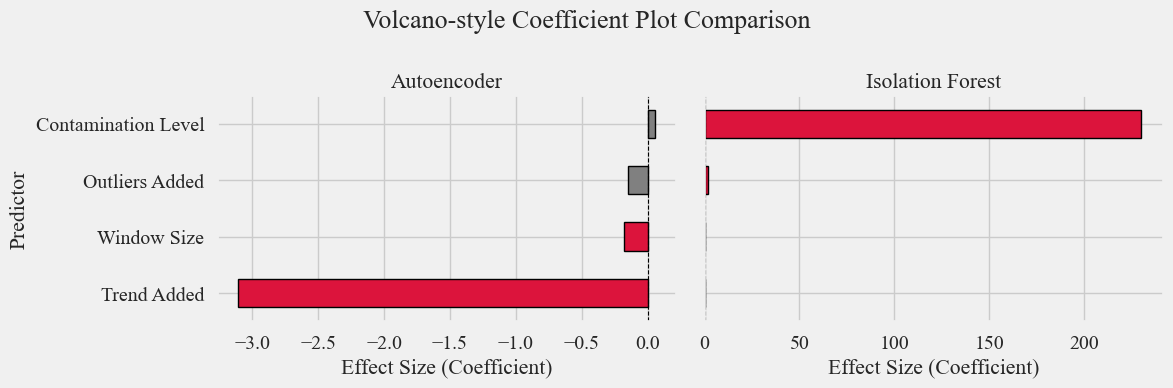


=== Metric Statistics ===
                               Metric       mean        std
0              % Overlap in Anomalies  18.740015  10.618300
1           Cohen’s Kappa (IOF vs AE)   0.240064   0.131055
2             Common anomalies (both)   5.052632   2.312684
3                 Fleiss’ Kappa (All)   0.287411   0.066712
4              Good at gradual trends        NaN        NaN
5      Jaccard Similarity (IOF vs AE)   0.156137   0.086260
6                  Robust to outliers        NaN        NaN
7          Sensitive to contamination        NaN        NaN
8   Sensitivity Test (Mean Anomalies)  17.475263   9.089783
9     Sensitivity Test (Mean Overlap)   3.696842   0.681469
10         Sensitivity to window size        NaN        NaN
11           Total anomalies detected  19.710526  10.415446
CPU times: total: 6h 10min 6s
Wall time: 6h 14min 38s


In [4]:
%%time
folder = r"C:\Users\prana\Desktop\directory\WildAlert_AnamolyModels\data\paper_exports\sporadic"
results_sporadic = run_full_anomaly_analysis(folder)